In [2]:
import numpy as np
import torch
import torch.nn as nn
import math

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
class GeometricTimeEmbedder(nn.Module):

    def __init__(self, frequency_embedding_size=256, start=1e-5, stop=0.25):
        super().__init__()
        self.frequency_embedding_size = frequency_embedding_size
        self.start=start
        self.stop=stop 
    
    def timestep_embedding(self, timesteps, dim):
        freqs = torch.tensor(np.geomspace(start=self.start, stop=self.stop, num=dim//2), dtype=timesteps.dtype).to(timesteps.device)
        args = timesteps[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
        return embedding

    def forward(self, t):
        t_emb = self.timestep_embedding(t, dim = self.frequency_embedding_size)
        return t_emb
    
class LinearTimeEmbedder(nn.Module):

    def __init__(self, frequency_embedding_size=256, start=1e-5, stop=0.25):
        super().__init__()
        self.frequency_embedding_size = frequency_embedding_size
        self.start=start
        self.stop=stop 
    
    def timestep_embedding(self, timesteps, dim):
        freqs = torch.tensor(np.linspace(start=self.start, stop=self.stop, num=dim//2), dtype=timesteps.dtype).to(timesteps.device)
        args = timesteps[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
        return embedding

    def forward(self, t):
        t_emb = self.timestep_embedding(t, dim = self.frequency_embedding_size)
        return t_emb

In [4]:
ts = torch.linspace(0, 7, 100)

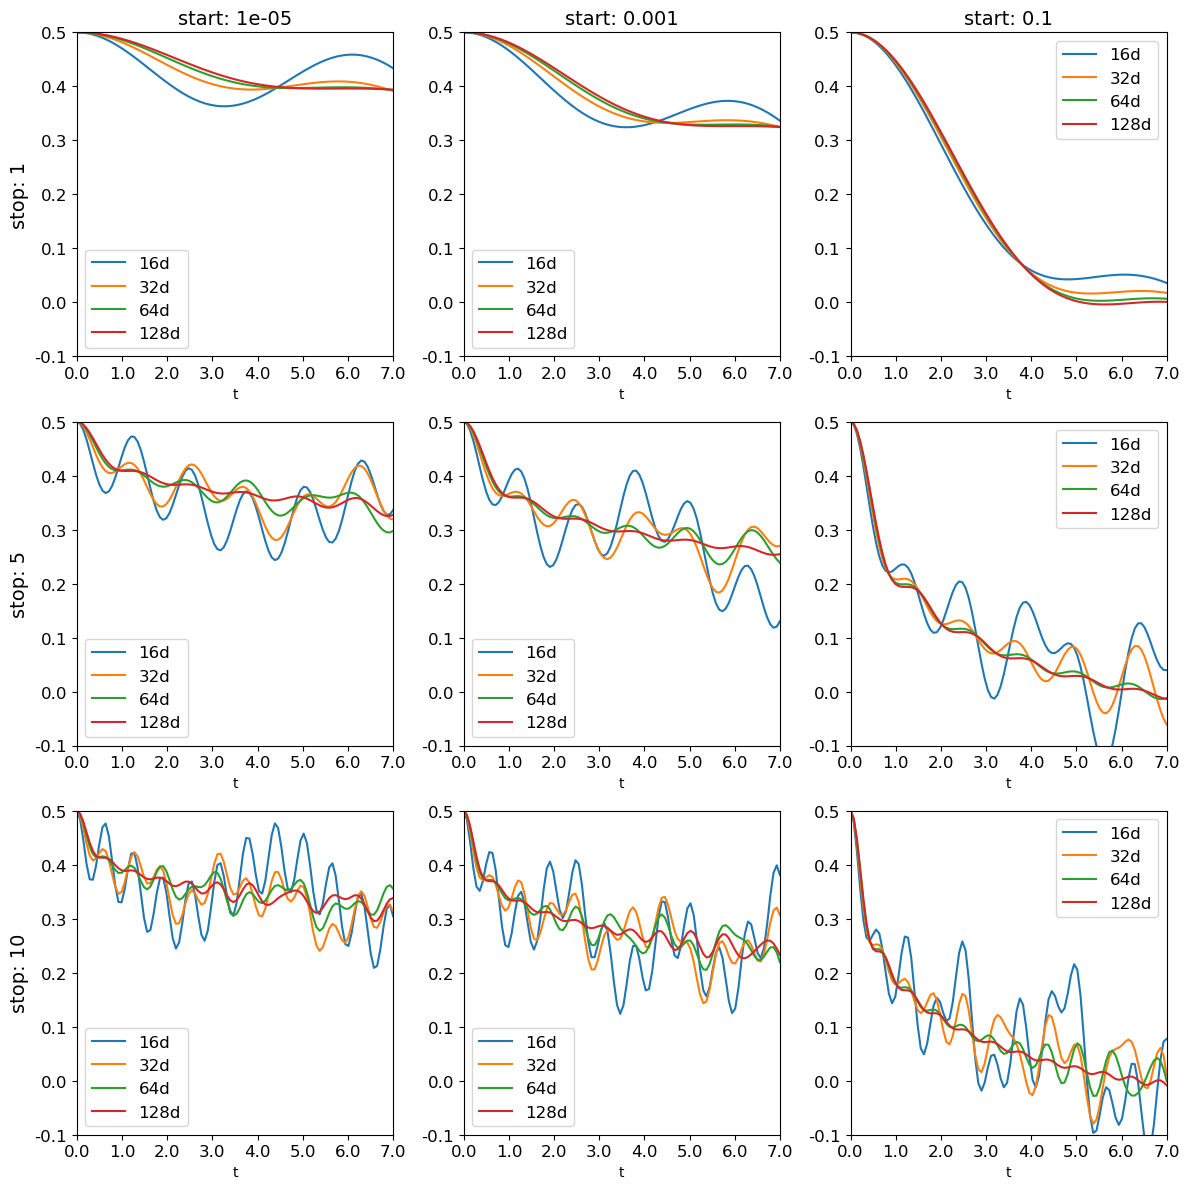

In [7]:
t_stops = [1, 5, 10]
t_starts = [1e-5, 1e-3, 0.1]
dims = [16, 32, 64,128]
fig, axs = plt.subplots(3,3, figsize=(12,12))
for r, t_stop in enumerate(t_stops):
    for c, t_start in enumerate(t_starts):
        for dim in dims:
            embedder = GeometricTimeEmbedder(frequency_embedding_size=dim, start = t_start, stop = t_stop)
            te = embedder(ts)
            dots = torch.einsum('nd,md->nm', te, te)/ te.shape[1] # normalize by embedding dimension
            sns.lineplot(x=ts.numpy(), y=dots[0].numpy(), ax=axs[r,c], label=f'{dim}d')

for ax in axs.flatten():
    ax.set_xlabel("t")
    ax.legend(fontsize=12)
    ax.set_xlim(0,7)
    ax.set_ylim(-0.1, 0.5)
    ax.set_yticks(np.arange(-0.1, 0.6, 0.1), labels=[f"{y:.1f}" for y in np.arange(-0.1, 0.6, 0.1)], fontsize=12)
    ax.set_xticks(np.arange(0, 8, 1), labels=[f"{x:.1f}" for x in np.arange(0, 8, 1)], fontsize=12)

for r in range(len(t_stops)):
    axs[r,0].set_ylabel(f"stop: {t_stops[r]}", fontsize = 14)

for c in range(len(t_starts)):
    axs[0,c].set_title(f"start: {t_starts[c]}", fontsize = 14)

fig.tight_layout()

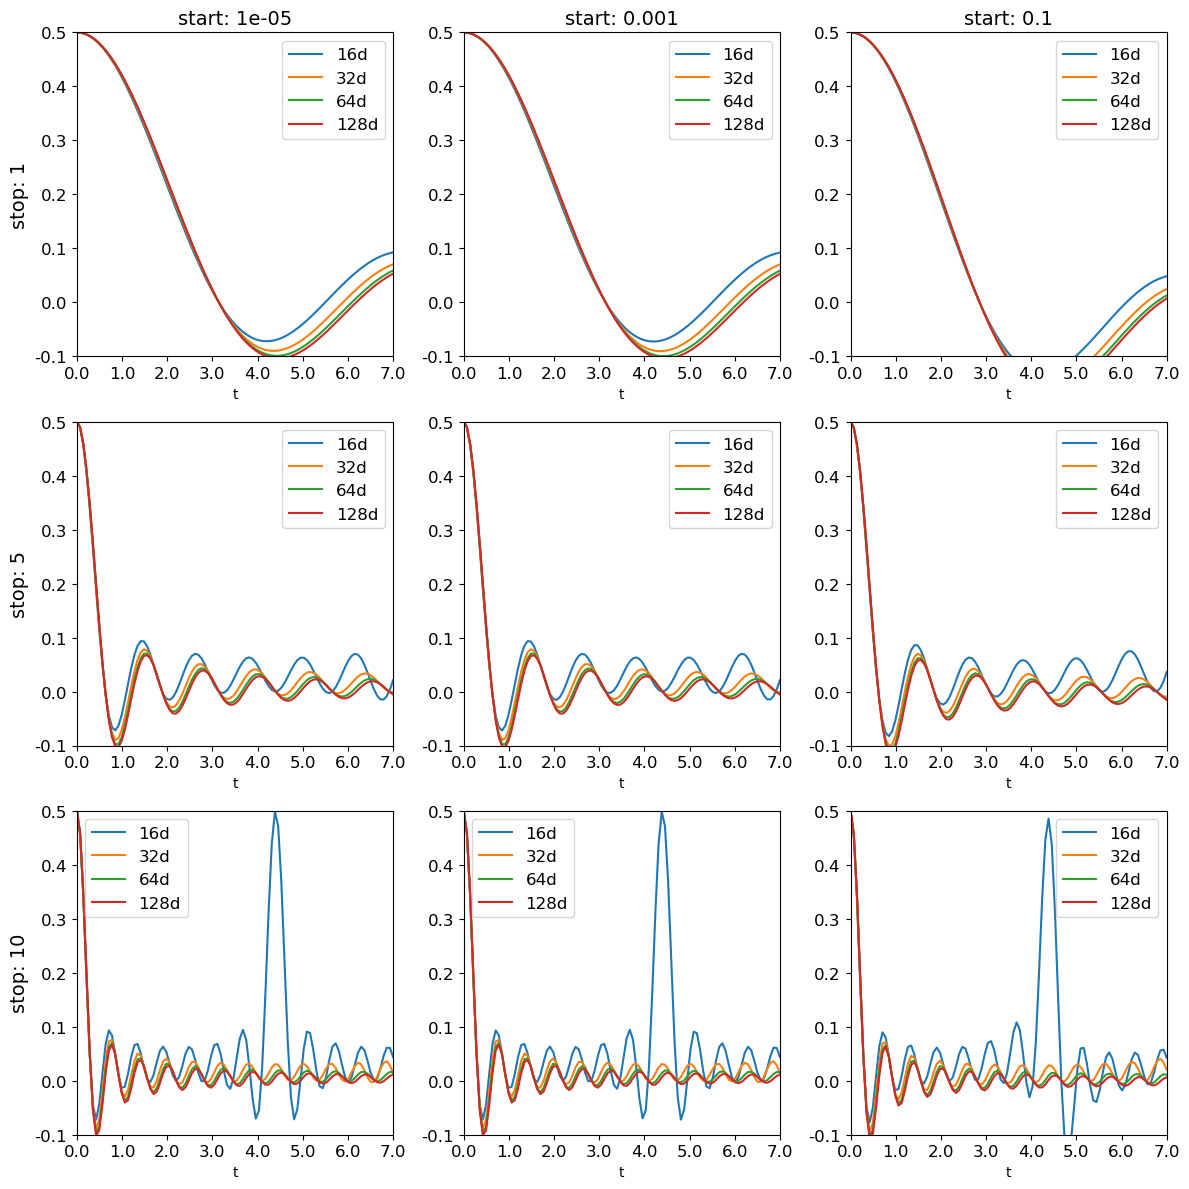

In [ ]:
t_stops = [1, 5, 10]
t_starts = [1e-5, 1e-3, 0.1]
dims = [16, 32, 64,128]
fig, axs = plt.subplots(3,3, figsize=(12,12))
for r, t_stop in enumerate(t_stops):
    for c, t_start in enumerate(t_starts):
        for dim in dims:
            embedder = LinearTimeEmbedder(frequency_embedding_size=dim, start = t_start, stop = t_stop)
            te = embedder(ts)
            dots = torch.einsum('nd,md->nm', te, te)/ te.shape[1] # normalize by embedding dimension
            sns.lineplot(x=ts.numpy(), y=dots[0].numpy(), ax=axs[r,c], label=f'{dim}d')

for ax in axs.flatten():
    ax.set_xlabel("t")
    ax.legend(fontsize=12)
    ax.set_xlim(0,7)
    ax.set_ylim(-0.1, 0.5)
    ax.set_yticks(np.arange(-0.1, 0.6, 0.1), labels=[f"{y:.1f}" for y in np.arange(-0.1, 0.6, 0.1)], fontsize=12)
    ax.set_xticks(np.arange(0, 8, 1), labels=[f"{x:.1f}" for x in np.arange(0, 8, 1)], fontsize=12)

for r in range(len(t_stops)):
    axs[r,0].set_ylabel(f"stop: {t_stops[r]}", fontsize = 14)

for c in range(len(t_starts)):
    axs[0,c].set_title(f"start: {t_starts[c]}", fontsize = 14)

fig.tight_layout()